### This notebook is used to automate canadian airline passenger forecasting

In [1]:
import requests
import json

### Operating and financial statistics for major Canadian airlines, monthly dataset PID:2310007901

In [2]:
payload = [{"productId":23100079}]

response = requests.post("https://www150.statcan.gc.ca/t1/wds/rest/getCubeMetadata", json=payload)

response.json()

[{'status': 'SUCCESS',
  'object': {'responseStatusCode': 0,
   'productId': '23100079',
   'cansimId': '401-0001',
   'cubeTitleEn': 'Operating and financial statistics for major Canadian airlines, monthly',
   'cubeTitleFr': "Statistiques d'exploitation et financières des principaux transporteurs aériens canadiens, mensuel",
   'cubeStartDate': '1981-01-01',
   'cubeEndDate': '2026-06-01',
   'frequencyCode': 6,
   'nbSeriesCube': 11,
   'nbDatapointsCube': 4690,
   'releaseTime': '2026-08-27T08:30',
   'archiveStatusCode': '2',
   'archiveStatusEn': 'CURRENT - a cube available to the public and that is current',
   'archiveStatusFr': 'ACTIF - un cube qui est disponible au public et qui est toujours mise a jour',
   'subjectCode': ['230105', '330305'],
   'surveyCode': ['5026'],
   'dimension': [{'dimensionPositionId': 1,
     'dimensionNameEn': 'Geography',
     'dimensionNameFr': 'Géographie',
     'hasUom': False,
     'member': [{'memberId': 1,
       'parentMemberId': None,
    

### Downloading and extracting the file from Stats Canada

In [3]:
response = requests.get("https://www150.statcan.gc.ca/t1/wds/rest/getFullTableDownloadCSV/23100079/en")
data = response.json()["object"]

print(data)

https://www150.statcan.gc.ca/n1/tbl/csv/23100079-eng.zip


In [4]:
download_zip = requests.get(data)

In [5]:
import zipfile
import io

with zipfile.ZipFile(io.BytesIO(download_zip.content)) as z:

    z.extractall("../dataset")

### Cleaning and Analysis

In [6]:
import pandas as pd

In [7]:
df = pd.read_csv("../dataset/23100079.csv")
df

,REF_DATE,GEO,DGUID,Operational and financial statistics,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1981-01,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.10,1895.0,NaN,NaN,NaN,0
1,1981-01,Canada,2021A000011124,Passenger-kilometres,Number,223,thousands,3,v11744,1.20,3411545.0,NaN,NaN,NaN,0
2,1981-01,Canada,2021A000011124,Kilograms of goods,Kilograms,192,thousands,3,v11745,1.30,29091.0,NaN,NaN,t,0
3,1981-01,Canada,2021A000011124,Goods tonne-kilometres,Tonne-kilometres,285,thousands,3,v11746,1.40,64084.0,NaN,NaN,t,0
4,1981-01,Canada,2021A000011124,Hours flown,Number,223,thousands,3,v11747,1.50,53.0,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4685,2026-06,Canada,2021A000011124,Available seat-kilometres,Number,223,thousands,3,v107645152,1.10,25474372.0,NaN,NaN,NaN,0
4686,2026-06,Canada,2021A000011124,Load factor,Percent,239,units,0,v107645153,1.11,85.2,NaN,NaN,NaN,1
4687,2026-06,Canada,2021A000011124,Hours flown,Number,223,thousands,3,v11747,1.50,194.0,NaN,NaN,NaN,0
4688,2026-06,Canada,2021A000011124,Turbo fuel consumed,Litres,203,thousands,3,v11748,1.60,690781.0,NaN,NaN,NaN,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4690 entries, 0 to 4689
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   REF_DATE                              4690 non-null   object 
 1   GEO                                   4690 non-null   object 
 2   DGUID                                 4690 non-null   object 
 3   Operational and financial statistics  4690 non-null   object 
 4   UOM                                   4690 non-null   object 
 5   UOM_ID                                4690 non-null   int64  
 6   SCALAR_FACTOR                         4690 non-null   object 
 7   SCALAR_ID                             4690 non-null   int64  
 8   VECTOR                                4690 non-null   object 
 9   COORDINATE                            4690 non-null   float64
 10  VALUE                                 4161 non-null   float64
 11  STATUS           

In [9]:
df = df[df["Operational and financial statistics"] == "Passengers"].reset_index(drop=True)
df

,REF_DATE,GEO,DGUID,Operational and financial statistics,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1981-01,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,1895.0,NaN,NaN,NaN,0
1,1981-02,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,1852.0,NaN,NaN,NaN,0
2,1981-03,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,2130.0,NaN,NaN,NaN,0
3,1981-04,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,2083.0,NaN,NaN,NaN,0
4,1981-05,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,2118.0,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,2026-02,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,6599.0,NaN,NaN,NaN,0
542,2026-03,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,7575.0,NaN,NaN,NaN,0
543,2026-04,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,7039.0,NaN,NaN,NaN,0
544,2026-05,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,7310.0,NaN,NaN,NaN,0


In [10]:
df["PASSENGERS"] = df["VALUE"]*1000
df

,REF_DATE,GEO,DGUID,Operational and financial statistics,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS,PASSENGERS
0,1981-01,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,1895.0,NaN,NaN,NaN,0,1895000.0
1,1981-02,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,1852.0,NaN,NaN,NaN,0,1852000.0
2,1981-03,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,2130.0,NaN,NaN,NaN,0,2130000.0
3,1981-04,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,2083.0,NaN,NaN,NaN,0,2083000.0
4,1981-05,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,2118.0,NaN,NaN,NaN,0,2118000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,2026-02,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,6599.0,NaN,NaN,NaN,0,6599000.0
542,2026-03,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,7575.0,NaN,NaN,NaN,0,7575000.0
543,2026-04,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,7039.0,NaN,NaN,NaN,0,7039000.0
544,2026-05,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,7310.0,NaN,NaN,NaN,0,7310000.0


In [11]:
df["REF_DATE"] = pd.to_datetime(df["REF_DATE"])
df = df.sort_values("REF_DATE")
df = df.set_index("REF_DATE")

In [12]:
df

,GEO,DGUID,Operational and financial statistics,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS,PASSENGERS
REF_DATE,,,,,,,,,,,,,,,
1981-01-01,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,1895.0,NaN,NaN,NaN,0,1895000.0
1981-02-01,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,1852.0,NaN,NaN,NaN,0,1852000.0
1981-03-01,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,2130.0,NaN,NaN,NaN,0,2130000.0
1981-04-01,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,2083.0,NaN,NaN,NaN,0,2083000.0
1981-05-01,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,2118.0,NaN,NaN,NaN,0,2118000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-01,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,6599.0,NaN,NaN,NaN,0,6599000.0
2026-03-01,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,7575.0,NaN,NaN,NaN,0,7575000.0
2026-04-01,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,7039.0,NaN,NaN,NaN,0,7039000.0


In [13]:
df.drop(['GEO', 'DGUID', 'UOM', 'UOM_ID', 'SCALAR_ID', 'VECTOR', 'COORDINATE', 'STATUS', 'SYMBOL', 'TERMINATED', 'DECIMALS', 'Operational and financial statistics', 'SCALAR_FACTOR', 'VALUE'],  axis=1, inplace=True)

In [14]:
df

,PASSENGERS
REF_DATE,
1981-01-01,1895000.0
1981-02-01,1852000.0
1981-03-01,2130000.0
1981-04-01,2083000.0
1981-05-01,2118000.0
...,...
2026-02-01,6599000.0
2026-03-01,7575000.0
2026-04-01,7039000.0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 546 entries, 1981-01-01 to 2026-06-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   PASSENGERS  546 non-null    float64
dtypes: float64(1)
memory usage: 8.5 KB


In [16]:
df.isna().sum()

PASSENGERS    0
dtype: int64

In [17]:
df.index.is_monotonic_increasing

True

In [18]:
df["PASSENGERS"].describe()

count    5.460000e+02
mean     3.170714e+06
std      1.946212e+06
min      2.130000e+05
25%      1.832250e+06
50%      2.248000e+06
75%      3.592500e+06
max      8.463000e+06
Name: PASSENGERS, dtype: float64

In [19]:
df.tail()

,PASSENGERS
REF_DATE,
2026-02-01,6599000.0
2026-03-01,7575000.0
2026-04-01,7039000.0
2026-05-01,7310000.0
2026-06-01,7580000.0


# Visualization

In [20]:
import matplotlib.pyplot as plt

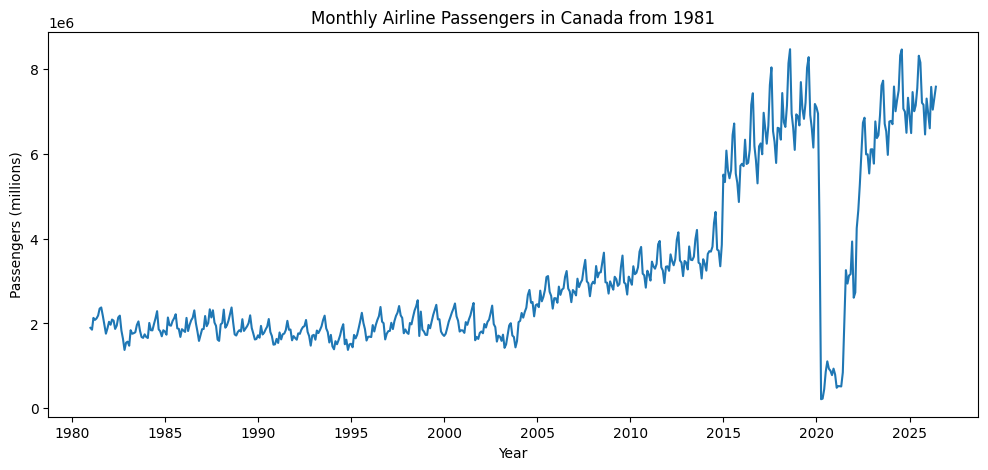

In [21]:
plt.figure(figsize= (12, 5))
plt.plot(df.index, df["PASSENGERS"])
plt.title("Monthly Airline Passengers in Canada from 1981")
plt.xlabel("Year")
plt.ylabel("Passengers (millions)")
plt.show()

### Modelling

In [22]:
from statsmodels.tsa.seasonal import seasonal_decompose

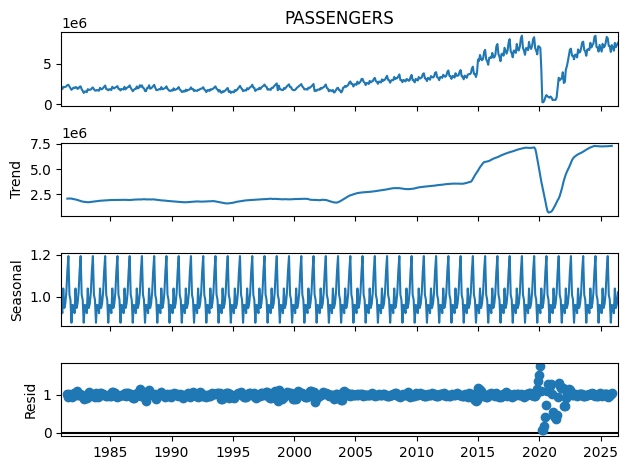

In [23]:
decompose = seasonal_decompose(df["PASSENGERS"], model="multiplicative", period=12)
decompose.plot()
plt.show()

In [24]:
from statsmodels.tsa.stattools import adfuller

In [25]:
adf_result = adfuller(df["PASSENGERS"])

print("ADF Statistics: ", adf_result[0])
print("p-value: ", adf_result[1])
print("Critical Values: ")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistics:  -1.5540535711400123
p-value:  0.5066227628924329
Critical Values: 
1%: -3.442819521824351
5%: -2.8670399588708047
10%: -2.5696992792614384


In [26]:
df_sesnl = df["PASSENGERS"].diff(12).dropna()

In [27]:
adf_result = adfuller(df_sesnl)

print("ADF Statistics: ", adf_result[0])
print("p-value: ", adf_result[1])
print("Critical Values: ")
for key, value in adf_result[4].items():
    print(f" {key}: {value}")

ADF Statistics:  -5.941210932357427
p-value:  2.258675505789522e-07
Critical Values: 
 1%: -3.4429882202506255
 5%: -2.8671142122781066
 10%: -2.569738849852071


In [28]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

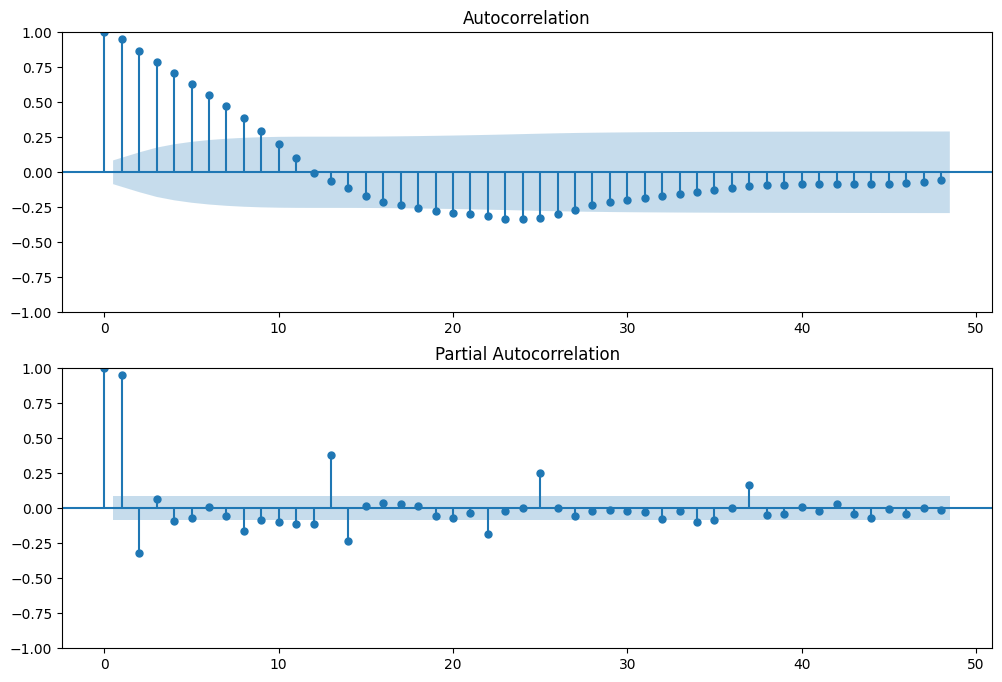

In [29]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df_sesnl, lags=48, ax=ax[0])
plot_pacf(df_sesnl, lags=48, ax=ax[1])
fig.show()

In [30]:
train = df.iloc[:-24]
test = df.iloc[-24:]

In [31]:
print(train.tail())

            PASSENGERS
REF_DATE              
2024-02-01   6696000.0
2024-03-01   7584000.0
2024-04-01   7001000.0
2024-05-01   7265000.0
2024-06-01   7491000.0


In [32]:
print(test.head())

            PASSENGERS
REF_DATE              
2024-07-01   8316000.0
2024-08-01   8457000.0
2024-09-01   7060000.0
2024-10-01   6991000.0
2024-11-01   6493000.0


In [33]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [34]:
model = SARIMAX(
    train["PASSENGERS"], order=(1, 0, 1),
    seasonal_order=(1, 1, 0, 12)
    )

/opt/hostedtoolcache/Python/3.12.14/x64/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/hostedtoolcache/Python/3.12.14/x64/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [35]:
model_fit = model.fit()
print(model_fit.params)

ar.L1       9.334075e-01
ma.L1       3.853437e-01
ar.S.L12   -4.302314e-01
sigma2      1.339641e+11
dtype: float64


In [36]:
print(model_fit.summary())

                                      SARIMAX Results                                      
Dep. Variable:                          PASSENGERS   No. Observations:                  522
Model:             SARIMAX(1, 0, 1)x(1, 1, [], 12)   Log Likelihood               -7221.495
Date:                             Tue, 01 Sep 2026   AIC                          14450.989
Time:                                     16:16:25   BIC                          14467.927
Sample:                                 01-01-1981   HQIC                         14457.630
                                      - 06-01-2024                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9334      0.009     99.704      0.000       0.915       0.952
ma.L1          0.3853      

In [37]:
forecast = model_fit.get_forecast(steps=24)
mean_forecast = forecast.predicted_mean
conf_int = forecast.conf_int()

### Testing the accuracy of the forecast

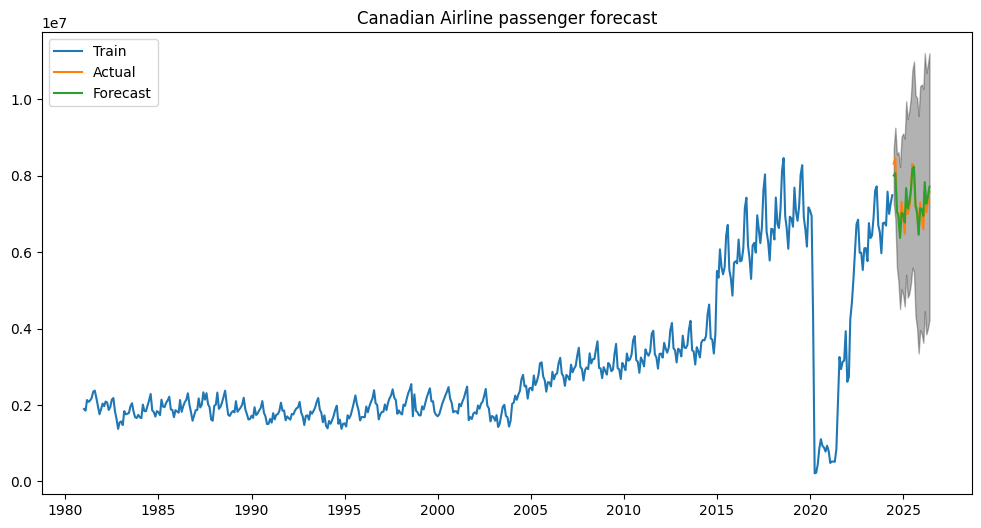

In [38]:
plt.figure(figsize=(12, 6))  
plt.plot(train.index, train["PASSENGERS"], label="Train")
plt.plot(test.index, test["PASSENGERS"], label="Actual")
plt.plot(mean_forecast.index, mean_forecast, label="Forecast")
plt.fill_between(conf_int.index, conf_int.iloc[:,0], conf_int.iloc[:,1], color="black", alpha=0.3)

plt.legend()
plt.title("Canadian Airline passenger forecast")
plt.show()

# Calculating MAPE and RMSE

In [39]:
from sklearn.metrics import mean_absolute_percentage_error

In [40]:
mape = mean_absolute_percentage_error(test["PASSENGERS"], mean_forecast)


In [41]:
print("MAPE: ", mape * 100)

MAPE:  2.2590814917743045


In [42]:
from sklearn.metrics import mean_squared_error
import numpy as np

In [43]:
rmse = np.sqrt(mean_squared_error(test["PASSENGERS"], mean_forecast))

In [44]:
print("RMSE: ", rmse)

RMSE:  195895.76691166573


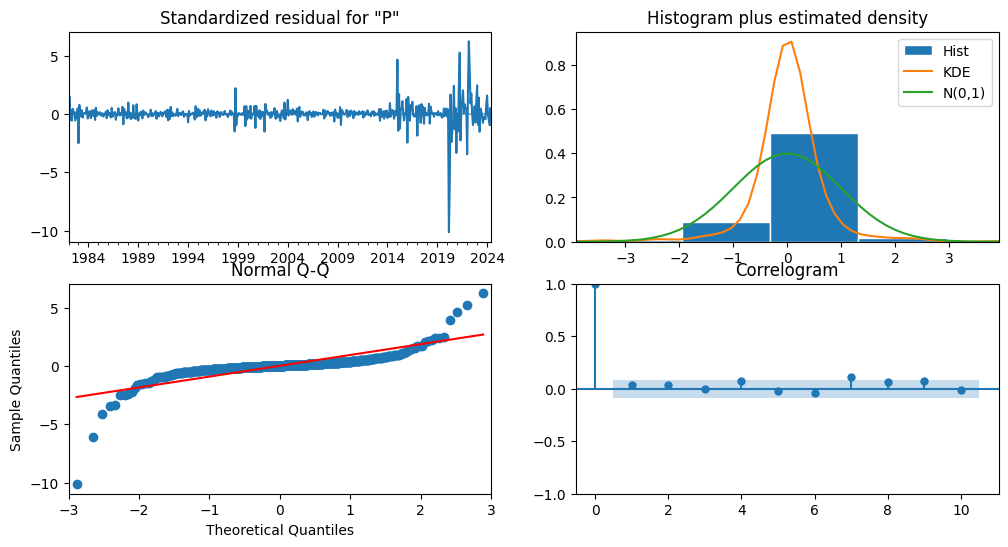

In [45]:
model_fit.plot_diagnostics(figsize=(12, 6))
plt.show()

# Final Modelling

In [46]:
final_model = SARIMAX(df["PASSENGERS"], order=(1, 0, 1), seasonal_order=(1, 1, 0, 12))

/opt/hostedtoolcache/Python/3.12.14/x64/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/hostedtoolcache/Python/3.12.14/x64/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [47]:
final_model_fit = final_model.fit()
print(final_model_fit.params)

ar.L1       9.330313e-01
ma.L1       3.807876e-01
ar.S.L12   -4.301088e-01
sigma2      1.298346e+11
dtype: float64


In [48]:
print(final_model_fit.summary())

                                      SARIMAX Results                                      
Dep. Variable:                          PASSENGERS   No. Observations:                  546
Model:             SARIMAX(1, 0, 1)x(1, 1, [], 12)   Log Likelihood               -7552.779
Date:                             Tue, 01 Sep 2026   AIC                          15113.557
Time:                                     16:16:26   BIC                          15130.679
Sample:                                 01-01-1981   HQIC                         15120.257
                                      - 06-01-2026                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9330      0.009    103.065      0.000       0.915       0.951
ma.L1          0.3808      

In [49]:
automated_forecasted_data = final_model_fit.get_forecast(steps=24)
mean_future_forecast = automated_forecasted_data.predicted_mean
future_conf_int = automated_forecasted_data.conf_int()

# Future Forecast

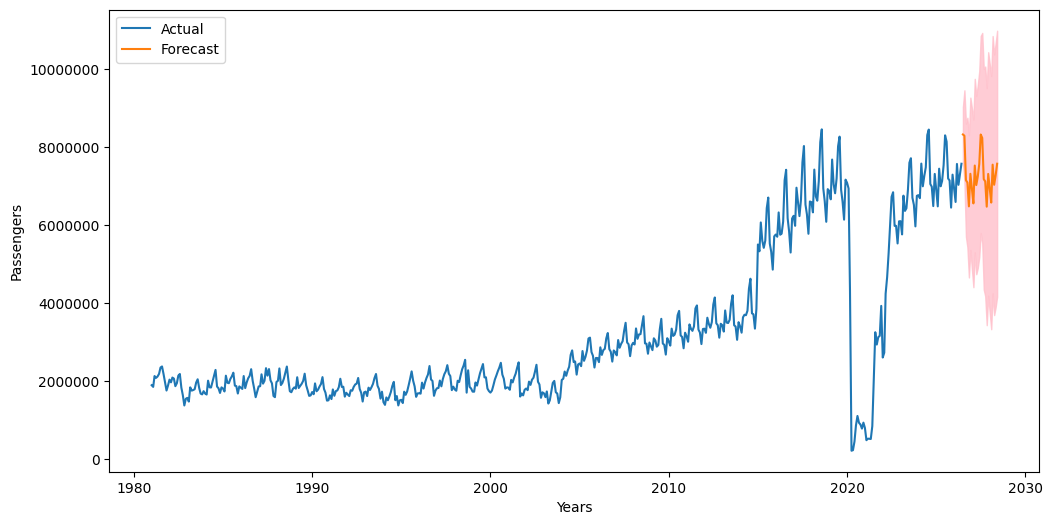

In [50]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["PASSENGERS"], label="Actual")
plt.plot(mean_future_forecast.index, mean_future_forecast, label="Forecast")
plt.fill_between(future_conf_int.index, future_conf_int.iloc[:,0], future_conf_int.iloc[:,1], color="pink", alpha=0.8)
plt.ticklabel_format(style='plain', axis='y')
plt.ylabel("Passengers")
plt.xlabel("Years")
plt.legend()
plt.savefig("../plots/automated_forecast.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [51]:
print(type(df))
print(df.columns)
print(df.head())

<class 'pandas.core.frame.DataFrame'>
Index(['PASSENGERS'], dtype='object')
            PASSENGERS
REF_DATE              
1981-01-01   1895000.0
1981-02-01   1852000.0
1981-03-01   2130000.0
1981-04-01   2083000.0
1981-05-01   2118000.0


In [52]:
automated_forecasted_data = pd.concat([mean_future_forecast, future_conf_int], axis=1)
automated_forecasted_data.columns = ["Forecast", "Lower_ci", "Upper_ci"]

In [53]:
df_plot = df.reset_index()
df_plot

,REF_DATE,PASSENGERS
0,1981-01-01,1895000.0
1,1981-02-01,1852000.0
2,1981-03-01,2130000.0
3,1981-04-01,2083000.0
4,1981-05-01,2118000.0
...,...,...
541,2026-02-01,6599000.0
542,2026-03-01,7575000.0
543,2026-04-01,7039000.0
544,2026-05-01,7310000.0


In [54]:
forecast_df = mean_future_forecast.reset_index()
forecast_df.columns = ["REF_DATE", "PASSENGERS"]
forecast_df

,REF_DATE,PASSENGERS
0,2026-07-01,8.331544e+06
1,2026-08-01,8.299129e+06
2,2026-09-01,7.157359e+06
3,2026-10-01,7.098618e+06
4,2026-11-01,6.485578e+06
5,2026-12-01,7.321984e+06
6,2027-01-01,6.942532e+06
7,2027-02-01,6.562422e+06
8,2027-03-01,7.533745e+06
9,2027-04-01,7.033123e+06


In [55]:
df_plot["category"] = "Actual"
forecast_df["category"] = "Forecast"

combined = pd.concat([df_plot, forecast_df], ignore_index=True)

# Interactive Visualization using altair

In [56]:
import altair as alt

nearest = alt.selection_point(nearest=True, on="pointerover",
                              fields=["REF_DATE"], empty=False)

actual = alt.Chart(df_plot).mark_line(color="blue").encode(
            x="REF_DATE:T",
            y="PASSENGERS:Q",
            tooltip=[
                "REF_DATE:T",
                "PASSENGERS:Q"
            ]
            )

forecast = alt.Chart(forecast_df).mark_line(color="red").encode(
    x="REF_DATE:T",
    y="PASSENGERS:Q",
    tooltip=[
        "REF_DATE:T",
        "PASSENGERS:Q"
    ]
    )

combined = pd.concat([df_plot, forecast_df])

selectors = alt.Chart(combined).mark_point().encode(
    x="REF_DATE:T",
    opacity=alt.value(0),
).add_params(nearest)

line = alt.Chart(combined).mark_line(interpolate="basis").encode(
    x="REF_DATE:T",
    y="PASSENGERS:Q",
    color="category:N"
)

when_near = alt.when(nearest)

points = line.mark_point().encode(
    opacity=when_near.then(alt.value(1)).otherwise(alt.value(0))
)


text = line.mark_text(
    align="left",
    dx=5,
    dy=-5,
    fontSize=14,
    fontWeight="bold"
    ).encode(
        text=when_near.then("PASSENGERS:Q").otherwise(alt.value(" ")),
        color="category:N"
    )


rules = alt.Chart(combined).mark_rule(color='black').encode(
    x="REF_DATE:T"
).transform_filter(nearest)

chart = alt.layer(actual, forecast, selectors, text, rules, points).properties(
    width=800,
    height=400
    )

chart.save("../forecast_html/aviation_forecast.html")
chart


alt.LayerChart(...)

In [57]:
automated_forecasted_data.tail(40)

,Forecast,Lower_ci,Upper_ci
2026-07-01,8.331544e+06,7.625319e+06,9.037769e+06
2026-08-01,8.299129e+06,7.133082e+06,9.465175e+06
2026-09-01,7.157359e+06,5.705076e+06,8.609643e+06
2026-10-01,7.098618e+06,5.436821e+06,8.760416e+06
2026-11-01,6.485578e+06,4.660871e+06,8.310284e+06
2026-12-01,7.321984e+06,5.366477e+06,9.277491e+06
2027-01-01,6.942532e+06,4.879899e+06,9.005165e+06
2027-02-01,6.562422e+06,4.410869e+06,8.713975e+06
2027-03-01,7.533745e+06,5.307673e+06,9.759817e+06
2027-04-01,7.033123e+06,4.744153e+06,9.322093e+06


### Forecast CSV

In [58]:
automated_forecasted_data.to_csv('../dataset/auto_forecast_data.csv')